### The goal for this competition is to predict whether an applicant is approved for a loan
https://kaggle.com/competitions/loan-approval-predictions

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 🌲 What is a Random Forest Classifier?

A **Random Forest Classifier** is a machine learning algorithm that helps us make predictions by combining the power of many smaller decision makers, called **decision trees**.

### 🌳 Start With One Decision Tree
Think of a **loan officer** reviewing applications:

- They check **income** → if high, likely approve.
- If income is low, then they look at **credit score**.
- Maybe then look at **employment history**.
  
This step-by-step process is exactly how a **decision tree** works.

But a single officer may have biases or make mistakes.  
Similarly, a **single decision tree** often overfits — it memorizes the training data too closely and performs poorly on new, unseen data.

---

## 🌲🌲🌲 Now Imagine a Forest of Loan Officers
Instead of relying on **one** officer, we consult **100 officers**.

- Each officer looks at **different slices of the data**.
- Each officer has a slightly different **decision process**.
- They each vote “approve” or “reject”.

The final decision is made by **majority vote**.  
This approach reduces bias, balances mistakes, and improves reliability.

This is the essence of **Random Forest**.

---

## 🧠 Why “Random”?
Randomness enters in two key ways:

1. **Random samples of the data** (called *bootstrap sampling*):
   Each tree trains on a different random subset of the dataset.

2. **Random subsets of features**:
   When building each tree, at each split it chooses from a random subset of features.
   This prevents all trees from making the same decisions.

The result: trees that *disagree* in useful ways → stronger model when combined.

---

## Basic Math Behind Random Forest

Let’s say we train **N** trees:

$$[T_1, T_2, T_3, \dots, T_N]$$

Each tree gives a classification for a new application:

$$T_i(x) \in \{0, 1\}$$

(0 = reject, 1 = approve)

The Random Forest final prediction is:

$$\hat{y} = \text{majority\_vote}(T_1(x), T_2(x), \dots, T_N(x))$$

For example, with **5 trees**:
- Predictions: `[1, 1, 0, 1, 0]`
- Approvals = 3 → **Approved** (majority = 1)


---

## 🎯 Why It Works Well (Especially For Business Problems)
- **More robust:** One weak decision tree may misjudge an applicant.  
  Many trees together smooth out errors.
- **Less overfitting:** Because data and features are randomized, it generalizes better.
- **Handles complexity:** Captures interactions (e.g., *income + credit score + loan amount*).
- **Minimal assumptions:** Works well even if the data isn't perfectly linear or clean.

---

## 🏁 Summary
A **Random Forest Classifier**:
- Builds many randomized decision trees.
- Lets each tree vote.
- Uses the majority vote as the final prediction.

It’s like having a **committee of experts** instead of a single person—more consistent and trustworthy in real-world decisions such as loan approval.


In [2]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [3]:
train_data.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [4]:
train_data['loan_status']

0        0
1        0
2        0
3        0
4        0
        ..
58640    0
58641    1
58642    1
58643    0
58644    0
Name: loan_status, Length: 58645, dtype: int64

In [5]:
test_data.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,58645,23,69000,RENT,3.0,HOMEIMPROVEMENT,F,25000,15.76,0.36,N,2
1,58646,26,96000,MORTGAGE,6.0,PERSONAL,C,10000,12.68,0.10,Y,4
2,58647,26,30000,RENT,5.0,VENTURE,E,4000,17.19,0.13,Y,2
3,58648,33,50000,RENT,4.0,DEBTCONSOLIDATION,A,7000,8.90,0.14,N,7
4,58649,26,102000,MORTGAGE,8.0,HOMEIMPROVEMENT,D,15000,16.32,0.15,Y,4


In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [7]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39098 entries, 0 to 39097
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39098 non-null  int64  
 1   person_age                  39098 non-null  int64  
 2   person_income               39098 non-null  int64  
 3   person_home_ownership       39098 non-null  object 
 4   person_emp_length           39098 non-null  float64
 5   loan_intent                 39098 non-null  object 
 6   loan_grade                  39098 non-null  object 
 7   loan_amnt                   39098 non-null  int64  
 8   loan_int_rate               39098 non-null  float64
 9   loan_percent_income         39098 non-null  float64
 10  cb_person_default_on_file   39098 non-null  object 
 11  cb_person_cred_hist_length  39098 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.6+ MB


In [8]:
train_data.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


### Understanding 25%, 50%, and 75% in `data.describe()`

When we run `data.describe()`, we get summary statistics for each numerical feature.  
The columns **25%**, **50%**, and **75%** are *percentiles* — they tell us how the data is distributed.

- **25% (First Quartile / Q1)**  
  This is the value below which **25% of the data falls**.  
  Think of it as: *1 out of every 4 observations is at or below this number.*  
  It represents the lower boundary of the "middle" of the data.

- **50% (Median / Q2)**  
  This is the **middle value** of the dataset.  
  Half of the observations are **below** it, and half are **above** it.  
  Unlike the average, the median is resistant to extreme values (outliers).

- **75% (Third Quartile / Q3)**  
  This is the value below which **75% of the data falls**.  
  It shows the upper boundary of the “middle” of the dataset.  
  Only the top 25% of values are greater than this number.

#### Why these matter
Together, these percentiles show how the data is spread.  
For example:
- If Q1 and Q3 are far apart, the data is widely dispersed.
- If the median is closer to Q1 than Q3, the data is slightly skewed upward.
- If the median is closer to Q3, the data is skewed downward.

These statistics make it easier to understand the distribution of your features before applying machine learning models.


In [9]:
missing_training_data = train_data.isnull().sum()
#counts number of null values and generates sum for each feature
missing_training_data

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [10]:
missing_test_data = test_data.isnull().sum()
missing_test_data

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

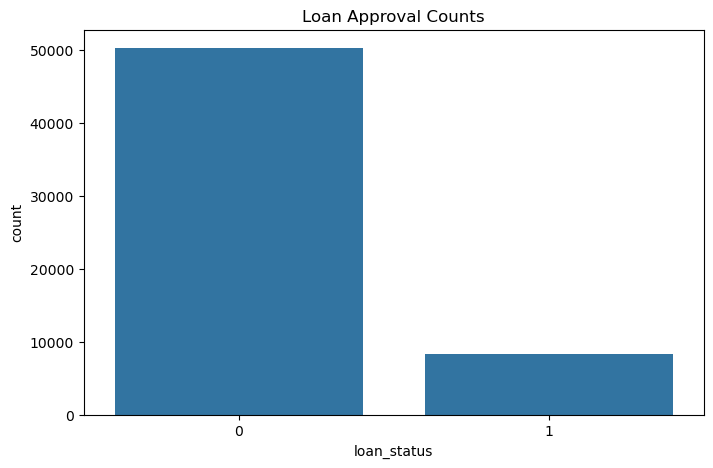

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='loan_status', data = train_data)
plt.title('Loan Approval Counts')
plt.show()

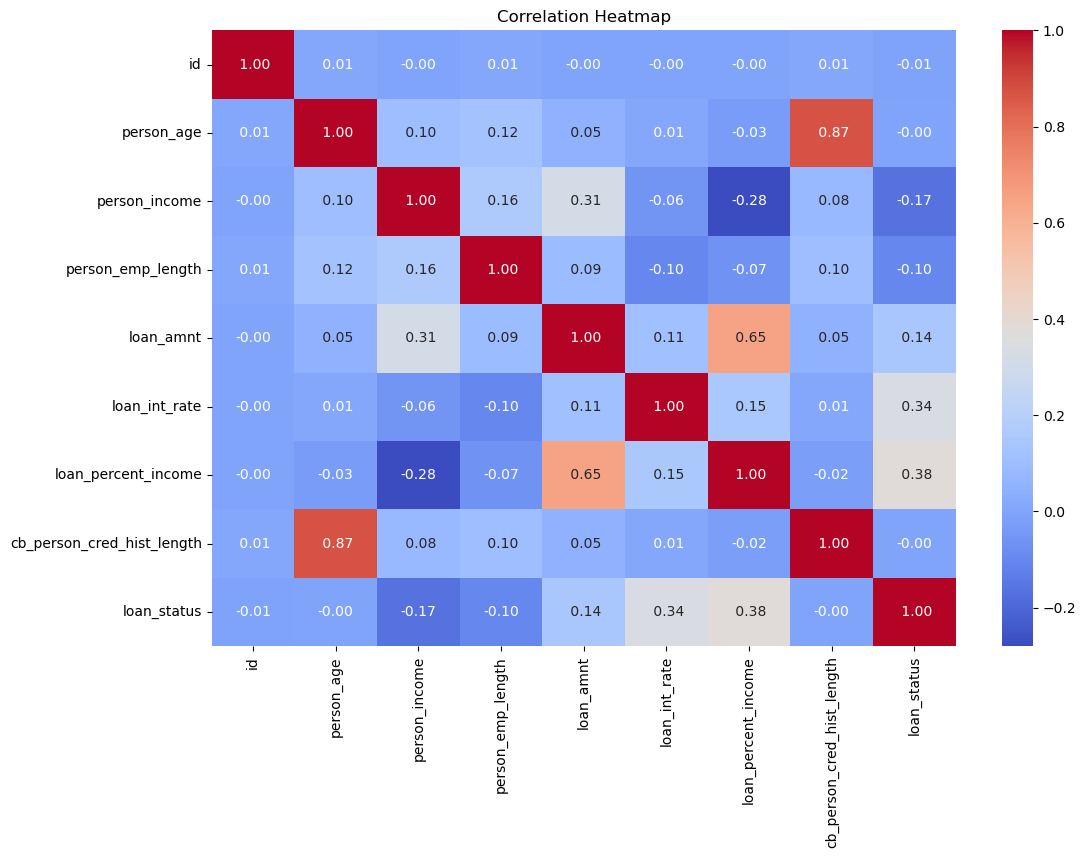

In [12]:
numeric_data = train_data.select_dtypes(include=[float,int])
#only include columns with numeric data type float and int
plt.figure(figsize=(12,8))
corr = numeric_data.corr()
sns.heatmap(corr, annot=True, fmt=' .2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
numeric_data

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
0,0,37,35000,0.0,6000,11.49,0.17,14,0
1,1,22,56000,6.0,4000,13.35,0.07,2,0
2,2,29,28800,8.0,6000,8.90,0.21,10,0
3,3,30,70000,14.0,12000,11.11,0.17,5,0
4,4,22,60000,2.0,6000,6.92,0.10,3,0
...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,5.0,25000,15.95,0.21,10,0
58641,58641,28,28800,0.0,10000,12.73,0.35,8,1
58642,58642,23,44000,7.0,6800,16.00,0.15,2,1
58643,58643,22,30000,2.0,5000,8.90,0.17,3,0


## 📊 Math Behind `numeric_data.corr()` (Pearson Correlation)

The Pearson correlation measures how two numeric variables move together relative to their spread.

### ✔️ Formula

$$
r_{X,Y} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\cdot\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

---

### 🔍 Intuition

1. Center each variable by subtracting its mean (these are the terms $(x_i - \bar{x})$ and $(y_i - \bar{y})$).  
2. Multiply paired centered values and sum: this captures whether they move together.  
3. Normalize by the spreads of \(X\) and \(Y\) so the result lies between -1 and +1.

### 📈 Interpretation

- \(r = +1\): perfect positive linear relationship  
- \(r = 0\): no linear relationship  
- \(r = -1\): perfect negative linear relationship


In [14]:
transformed_train_data = pd.get_dummies(train_data, drop_first = True)
X = transformed_train_data.drop('loan_status', axis = 1)
y=transformed_train_data['loan_status']

In [15]:
transformed_train_data

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,0,37,35000,0.0,6000,11.49,0.17,14,0,False,...,False,False,False,True,False,False,False,False,False,False
1,1,22,56000,6.0,4000,13.35,0.07,2,0,False,...,True,False,False,False,True,False,False,False,False,False
2,2,29,28800,8.0,6000,8.90,0.21,10,0,False,...,False,True,False,False,False,False,False,False,False,False
3,3,30,70000,14.0,12000,11.11,0.17,5,0,False,...,False,False,True,True,False,False,False,False,False,False
4,4,22,60000,2.0,6000,6.92,0.10,3,0,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,5.0,25000,15.95,0.21,10,0,False,...,False,False,False,False,False,True,False,False,False,True
58641,58641,28,28800,0.0,10000,12.73,0.35,8,1,False,...,True,False,False,False,True,False,False,False,False,False
58642,58642,23,44000,7.0,6800,16.00,0.15,2,1,False,...,False,False,False,False,False,True,False,False,False,False
58643,58643,22,30000,2.0,5000,8.90,0.17,3,0,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
transformed_test_data = pd.get_dummies(test_data, drop_first = True)

## 🔹 What is `pd.get_dummies()`?

`pd.get_dummies()` is a function in pandas that **converts categorical variables into numeric form** so that machine learning models can use them.

---

### 🧩 Why it’s needed

Most ML models (like Random Forest, SVM, or Logistic Regression) **cannot directly use text categories** such as:

- Gender: "Male", "Female"
- Loan Type: "Personal", "Home", "Car"

Models need numbers, but assigning arbitrary numbers can be misleading.  
For example, if we encode "Male"=1 and "Female"=2, the model might think Female > Male, which is **wrong**.

`pd.get_dummies()` solves this with **one-hot encoding**.

---

### 🌟 Analogy

Imagine a set of colored balls:

- Red, Green, Blue

Instead of giving them numbers 1,2,3, you create **a switch for each color**:

| Red | Green | Blue |
|-----|-------|------|
| 1   | 0     | 0    | (Red)  
| 0   | 1     | 0    | (Green)  
| 0   | 0     | 1    | (Blue)  

Each ball is now represented in a way the computer can understand **without implying order**.

---
## 🔹 One-Hot Encoding (Mathematical View)

`pd.get_dummies()` implements **one-hot encoding**, which can be expressed mathematically.

---

### Suppose a categorical variable X has k categories:
$
X = \{C_1, C_2, \dots, C_k\}
$
One-hot encoding transforms each observation $x_i$ in $X$ into a **k-dimensional vector** $v_i$:

$
v_i = [v_{i1}, v_{i2}, \dots, v_{ik}]
$

Where:

$
v_{ij} =
\begin{cases} 
1 & \text{if } x_i = C_j \\
0 & \text{otherwise}
\end{cases}
$

---

### Example

If `LoanType` = ["Home", "Personal", "Car"], then:

- "Home" → [1, 0, 0]  
- "Personal" → [0, 1, 0]  
- "Car" → [0, 0, 1]  

This is exactly what `pd.get_dummies()` produces.

---

### Why this is important for ML

1. Converts **text categories into numeric vectors** that models can use.  
2. Avoids introducing **false order** (no category is “larger” than another).  
3. Ensures features are **independent**, so algorithms like Random Forest or Logistic Regression can handle them properly.

---

### Optional: Drop first category

Sometimes we remove one column (drop_first=True) to avoid redundancy:

- Only k-1 vectors are kept.  
- The dropped category can be inferred from the remaining ones.  

This is called avoiding the **dummy variable trap**.



In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

In [18]:
model = RandomForestClassifier(random_state = 42)

In [19]:
param_dist = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=15,          # how many combinations to try
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 40, 'bootstrap': False}


# Random Forest & RandomizedSearchCV — Hyperparameter Explanation

---

## 🌳 Random Forest — Hyperparameter Explanation

### **`n_estimators`**
- **Meaning:** Number of trees in the forest.
- **Effect:** More trees → more stable & accurate model, but slower.
- **Analogy:** Like voting. The more voters (trees), the more reliable the decision.
- **Tip:** Common range: **100–1000**.

---

### **`max_depth`**
- **Meaning:** Maximum depth (levels) a tree can grow.
- **If `None`:** Trees grow until leaves are pure.
- **Analogy:** Depth = how deep you ask questions.
  - Shallow depth → simple, general decisions.
  - Deep depth → very specific, potentially overfitting.
- **Tip:** Smaller depth reduces overfitting.

---

### **`min_samples_split`**
- **Meaning:** Minimum samples needed in a node to allow a split.
- **Effect:**
  - Small value → very detailed trees (overfitting risk).
  - Large value → simpler trees (better generalization).
- **Analogy:** You only divide a classroom into smaller groups if enough students are present.

---

### **`min_samples_leaf`**
- **Meaning:** Minimum samples required in a leaf (end node).
- **Purpose:** Prevents tiny leaves that memorize noise.
- **Tip:** Try values like **1, 2, 4**.
- **Analogy:** You don't form a group if only 1 student shows up.

---

### **`bootstrap`**
- **Meaning:** Whether sampling is done with replacement.
- **`True`:** Uses bootstrap sampling (default).
- **`False`:** Uses the full dataset to build each tree.
- **Analogy:**
  - Bootstrap = pick a ball, record color, put back, pick again.
  - Non-bootstrap = once picked, it’s removed from the bag.

---


# 🎯 RandomizedSearchCV — Argument Explanation

### **`estimator`**
- The model you want to tune.
- Example: `RandomForestClassifier()`
- Think of it as the machine you’re tuning.

---

### **`param_distributions`**
- A dictionary of parameters and possible values.
- RandomizedSearchCV does **not** check all combinations—it samples randomly.
- **Analogy:** Shoe shopping. Instead of trying every brand, size, and color, you try random combinations unitl you find a good fit.

---

### **`n_iter`**
- Number of random combinations to test
- Higher -> better search coverage, longer runtime
- **Analogy:** Lottery tickets. More tickets -> better chance of winning

---

### **`scoring`**
- **Meaning:** Metric used to judge model performance.
- **Common metrics:**
  - `"accuracy"`
  - `"roc_auc"`
  - `"f1"`
  - `"precision"`
- **Analogy:** Scoring defines what “good” means — fastest, prettiest, or strongest.

---

### **`cv`**
- **Meaning:** Number of cross-validation folds.
- **How it works:**
  - Dataset is split into **k parts**
  - Model trains on **k−1 parts**
  - Model tests on **the remaining part**
- **Analogy:** 3 mock exams taken separately → average the scores to understand your true performance.

---

### **`random_state`**
- **Meaning:** Seed for reproducibility.
- **Purpose:** Ensures every run returns the same random choices.
- **Analogy:** Shuffle a deck the exact same way every time.

---

### **`verbose`**
- **Meaning:** Controls how much progress the model prints during training.
- **Values:**
  - `0` — silent
  - `2` — detailed logs
- **Analogy:** How much the model “talks” to you while working.

---

### **`n_jobs`**
- **Meaning:** Number of CPU cores to use.
- **Values:**
  - `-1` — use **all available cores**
- **Analogy:** More workers digging → hole finished faster.

---

# 🏁 Quick Summary Table

| Parameter | What it Controls | Why it Matters |
|---------|------------------|----------------|
| `n_estimators` | Number of trees | More stable results |
| `max_depth` | Tree depth | Controls overfitting |
| `min_samples_split` | Samples to split a node | Simplicity vs complexity |
| `min_samples_leaf` | Samples required per leaf | Avoid tiny overfit leaves |
| `bootstrap` | Sampling style | Stability vs efficiency |
| `n_iter` | Trials in hyperparameter search | Quality of exploration |
| `scoring` | Evaluation metric | Defines what “good” means |
| `cv` | Cross-validation folds | Reliable testing |
| `random_state` | Random seed | Reproducible results |
| `verbose` | Logging level | Visibility |
| `n_jobs` | CPU cores | Speed |



In [20]:
preds_ytest = search.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds_ytest))
print("\nClassification report: \n", classification_report(y_test, preds_ytest))

Accuracy: 0.9514025066075539

Classification report: 
               precision    recall  f1-score   support

           0       0.96      0.99      0.97     10087
           1       0.92      0.72      0.80      1642

    accuracy                           0.95     11729
   macro avg       0.94      0.85      0.89     11729
weighted avg       0.95      0.95      0.95     11729



## 📊 Understanding Model Evaluation: Accuracy & Classification Report

When we evaluate a classification model such as **RandomForestClassifier**, two important outputs are:

### ✔️ 1. Accuracy

**Accuracy** measures the proportion of correct predictions out of all predictions.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

- **TP (True Positives):** Model correctly predicted approvals.
- **TN (True Negatives):** Model correctly predicted rejections.
- **FP (False Positives):** Model incorrectly predicted approval.
- **FN (False Negatives):** Model incorrectly predicted rejection.

For our model:

> **Accuracy = 0.9514025066075539**

👉 This means the model makes correct predictions **~95.14%** of the time.

---

## 📑 2. Classification Report

This report gives a more detailed performance breakdown for each class.

---

### ✔️ Precision

**How many predicted approvals were truly approvals?**

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

- Class **1 (approved)**: precision = 0.92 → 92% of predicted approvals were real approvals.
- High precision = fewer false approvals.

---

### ✔️ Recall

**How many real approvals did the model correctly detect?**

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

- Class **1 (approved)**: recall = 0.72 → the model correctly found 72% of approved cases.
- Lower recall means it **misses some real approvals**.

---

### ✔️ F1-Score

Balances precision and recall (useful if one is high and the other is low).

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

- Class **1** has F1 = 0.80 → a good compromise between accuracy and completeness.

---

### ✔️ Support

**Number of actual samples for that class.**

- Class 0: 10,087 customers
- Class 1: 1,642 customers

This shows **class imbalance** → most loans were rejected.

---

## 📌 Macro Avg vs Weighted Avg

### 🔶 Macro Average
Average score over both classes, **treating them equally**.

- Does not care if one class has 100 samples and the other 10,000.
- Good for fairness evaluation between classes.

### 🔷 Weighted Average
Average score weighted by **how many samples each class has**.

- Reflects real-world performance better.
- Larger classes have more influence.

---

### ⭐ Key takeaway

- The model is **very strong for class 0 (loan rejected)**.
- It is **moderate for class 1 (approved loans)** — lower recall means it sometimes misses eligible applicants.
- Depending on business needs, you may want to improve recall for approvals.



In [21]:
test_predict = search.predict(transformed_test_data)

In [22]:
transformed_test_data

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,58645,23,69000,3.0,25000,15.76,0.36,2,False,False,...,False,False,False,False,False,False,False,True,False,False
1,58646,26,96000,6.0,10000,12.68,0.10,4,False,False,...,False,True,False,False,True,False,False,False,False,True
2,58647,26,30000,5.0,4000,17.19,0.13,2,False,False,...,False,False,True,False,False,False,True,False,False,True
3,58648,33,50000,4.0,7000,8.90,0.14,7,False,False,...,False,False,False,False,False,False,False,False,False,False
4,58649,26,102000,8.0,15000,16.32,0.15,4,False,False,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39093,97738,22,31200,2.0,3000,10.37,0.10,4,False,False,...,False,False,False,True,False,False,False,False,False,False
39094,97739,22,48000,6.0,7000,6.03,0.15,3,False,False,...,False,False,False,False,False,False,False,False,False,False
39095,97740,51,60000,0.0,15000,7.51,0.25,25,False,False,...,False,True,False,False,False,False,False,False,False,False
39096,97741,22,36000,4.0,14000,15.62,0.39,4,False,False,...,False,True,False,False,False,True,False,False,False,True


In [23]:
submission_df = pd.DataFrame({"id":transformed_test_data.id,
                             "loan_status": test_predict})
submission_df.to_csv('submission1_uk.csv', index = False)